In [1]:
import mlflow
from mlflow.tracking import MlflowClient
import pandas as pd

mlflow.set_tracking_uri("http://localhost:5000") 

client = MlflowClient()

# Search for runs within a specific experiment
runs = client.search_experiments(filter_string="name = 'ESP32_Optuna_Tuning'")
experiment = runs[0]
print('Experiments found: ', len(runs))
for experiment in runs:
    print(f"Experiment ID: {experiment.experiment_id}, Name: {experiment.name}")

print("\nDetailed runs in the experiment:")
# List all runs in the experiment
experiment_id = experiment.experiment_id
RUN_NAME = "Optuna_Session_v4_Reward_Tuning"
filter = f'tags.`git.branch`="exp/optuna-v4" and attributes.run_name != "{RUN_NAME}"'
all_runs = client.search_runs(experiment_ids=[experiment_id], filter_string=filter)

for run in all_runs[:10]:
    print(f"Run ID: {run.info.run_id}, ParentId: {run.data.tags.get('mlflow.parentRunId', 'N/A')}, Name: {run.data.tags.get('mlflow.runName', 'N/A')}, Metrics: {run.data.metrics}, Params: {run.data.params}")



data = [{   **run.data.metrics,
            **run.data.params,
            'run_id': run.info.run_id,
            'parent_run_id': run.data.tags.get('mlflow.parentRunId', None),
            'run_name': run.data.tags.get('mlflow.runName', None),
            'batch_size': int(run.data.params.get('batch_size', 0)),
            'epsilon': float(run.data.metrics.get('epsilon', 0.0)),
            'learning_rate': float(run.data.params.get('learning_rate', 0.0)),
            'max_steps': int(run.data.params.get('max_steps', 0)),
            'episodes': int(run.data.params.get('episodes', 0)),
            'epsilon_decay': float(run.data.params.get('epsilon_decay', 0.0)),
        } 
for run in all_runs]

df = pd.DataFrame(data)
print("\nDataFrame of runs:")
print(df.describe())


Experiments found:  1
Experiment ID: 787176341010319053, Name: ESP32_Optuna_Tuning

Detailed runs in the experiment:
Run ID: c56e6da8156141ca8d98f1e745cf6d8d, ParentId: 0d7d5d718bd04b6f993c6986d70403e6, Name: opt_reward_tuning_trial_029, Metrics: {'act_back_pct': 0.17333333333333334, 'act_fwd_pct': 0.7377777777777778, 'act_left_pct': 0.08, 'act_right_pct': 0.0, 'act_stop_pct': 0.008888888888888889, 'avg_distance': 3.0807903148939264, 'avg_loss': 0.05460947213901414, 'crash_rate': 0.0, 'epsilon': 0.04822417719226521, 'fail_reason': 0.0, 'final_dist': 2.405270873727385, 'final_idle': 0.30888888888888894, 'idle_ratio': 0.08888888888888889, 'optuna_score': 19.130244435192264, 'reward': 13.765333342534598}, Params: {'architecture': 'DQN_3_64_64_5', 'batch_size': '128', 'episodes': '50', 'epsilon_decay': '0.9400000000000001', 'learning_rate': '5.3700535219067216e-06', 'max_steps': '225'}
Run ID: 3ab4fe31bcd74361a76fd75082fd0a86, ParentId: 0d7d5d718bd04b6f993c6986d70403e6, Name: opt_reward_tu

In [4]:
df[df['max_steps'] == 250]

,act_back_pct,act_fwd_pct,act_left_pct,act_right_pct,act_stop_pct,avg_distance,avg_loss,crash_rate,epsilon,fail_reason,...,reward,architecture,batch_size,episodes,epsilon_decay,learning_rate,max_steps,run_id,parent_run_id,run_name
1,0.284000,0.652000,0.048000,0.008000,0.008000,3.063126,0.030136,0.000,0.048587,0.0,...,6.388972,DQN_3_64_64_5,128,50,0.935,0.000007,250,3ab4fe31bcd74361a76fd75082fd0a86,0d7d5d718bd04b6f993c6986d70403e6,opt_reward_tuning_trial_028
3,0.356000,0.592000,0.032000,0.012000,0.008000,2.708637,0.040186,0.000,0.059100,0.0,...,13.678458,DQN_3_64_64_5,128,50,0.945,0.000005,250,693a9c7db3b348ea83fa7bbdc4b59076,0d7d5d718bd04b6f993c6986d70403e6,opt_reward_tuning_trial_026
5,0.256000,0.680000,0.012000,0.036000,0.016000,2.721871,0.064157,0.000,0.047455,0.0,...,11.155012,DQN_3_64_64_5,128,50,0.930,0.000010,250,44f21405691d453fa5cd034efe6e5b11,0d7d5d718bd04b6f993c6986d70403e6,opt_reward_tuning_trial_024
6,0.444000,0.492000,0.008000,0.052000,0.004000,3.047038,0.050054,0.000,0.048224,0.0,...,-12.673232,DQN_3_64_64_5,128,50,0.940,0.000008,250,b9f80192162b4b8896f77d91087fdc48,0d7d5d718bd04b6f993c6986d70403e6,opt_reward_tuning_trial_023
7,0.000000,1.000000,0.000000,0.000000,0.000000,0.988738,0.265741,0.004,0.048587,0.0,...,-9.301470,DQN_3_64_64_5,128,50,0.935,0.000009,250,ade658b1a8fc42e2a911bfc38575f81c,0d7d5d718bd04b6f993c6986d70403e6,opt_reward_tuning_trial_022
8,0.008000,0.812000,0.012000,0.156000,0.012000,2.921180,0.045830,0.000,0.048587,0.0,...,27.199432,DQN_3_64_64_5,128,50,0.935,0.000009,250,522489600df44f53b859c719e7cd191a,0d7d5d718bd04b6f993c6986d70403e6,opt_reward_tuning_trial_021
9,0.468000,0.508000,0.004000,0.016000,0.004000,2.883418,0.023335,0.000,0.048224,0.0,...,-12.637029,DQN_3_64_64_5,128,50,0.940,0.000009,250,a9646adba5fd40f29181c61acfd0f704,0d7d5d718bd04b6f993c6986d70403e6,opt_reward_tuning_trial_020
12,0.188000,0.740000,0.052000,0.012000,0.008000,3.070104,0.042775,0.000,0.059100,0.0,...,10.876035,DQN_3_64_64_5,128,50,0.945,0.000010,250,5e7e7042a89d4fb0b4b5b1bc8c98fece,0d7d5d718bd04b6f993c6986d70403e6,opt_reward_tuning_trial_017
15,0.021277,0.680851,0.000000,0.297872,0.000000,3.128902,0.047198,0.004,0.059100,0.0,...,-2.592280,DQN_3_64_64_5,128,50,0.945,0.000009,250,db02d793b695428a846a357ca9898cac,0d7d5d718bd04b6f993c6986d70403e6,opt_reward_tuning_trial_014
17,0.014085,0.767606,0.007042,0.204225,0.007042,2.675603,0.061896,0.004,0.048587,0.0,...,2.270900,DQN_3_64_64_5,128,50,0.935,0.000006,250,0950d7c95e5841aa9780ab79f140801f,0d7d5d718bd04b6f993c6986d70403e6,opt_reward_tuning_trial_012


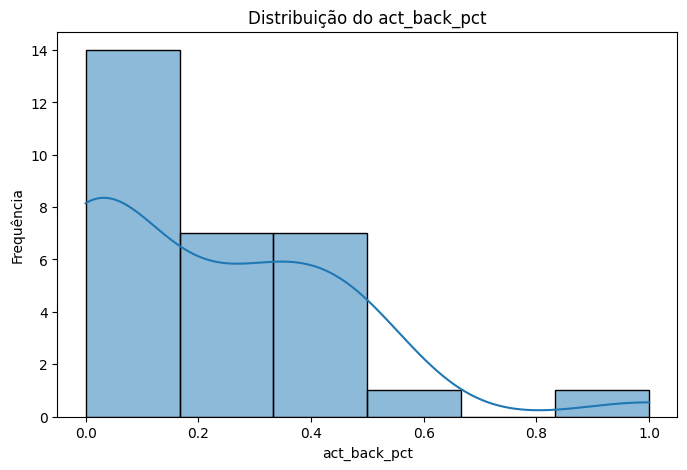

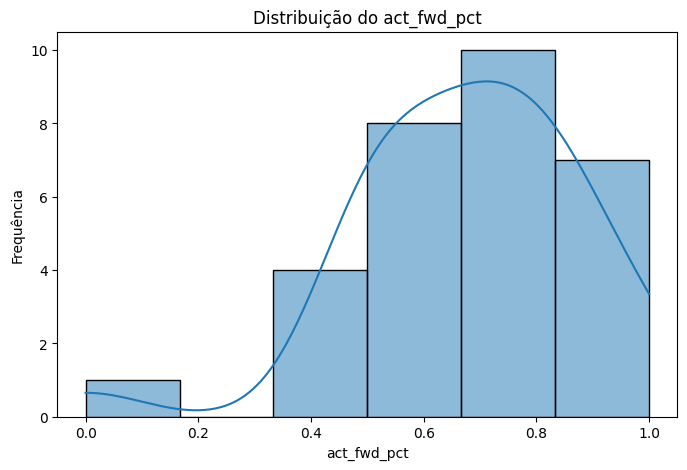

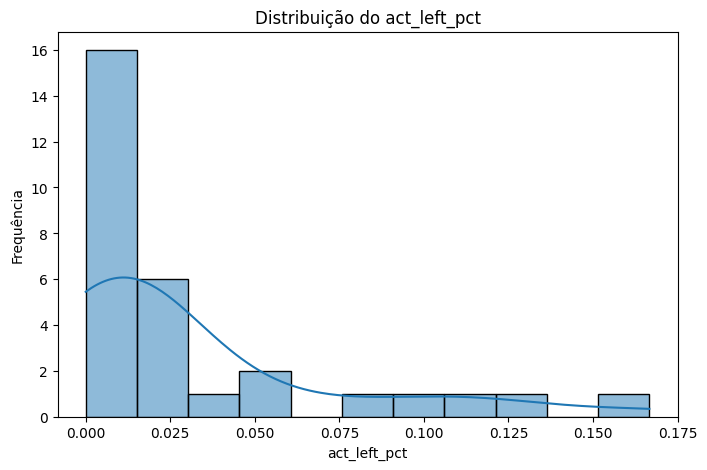

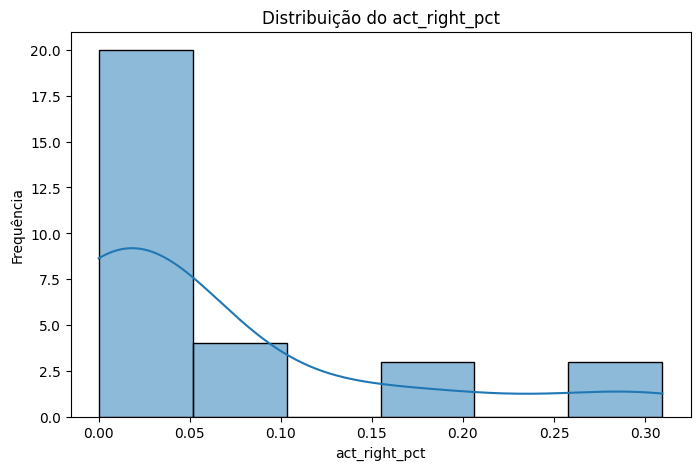

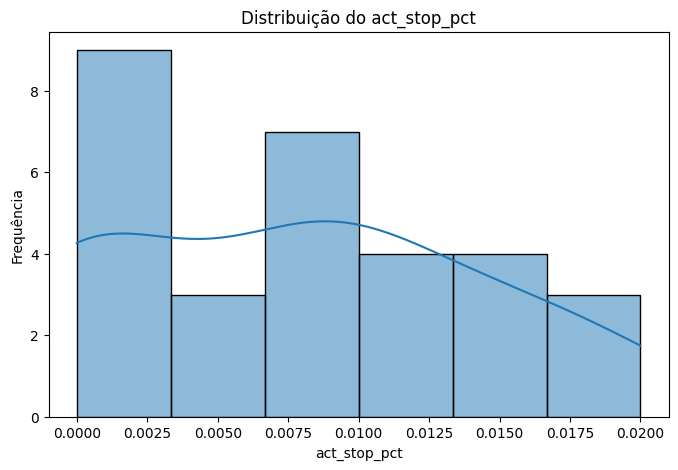

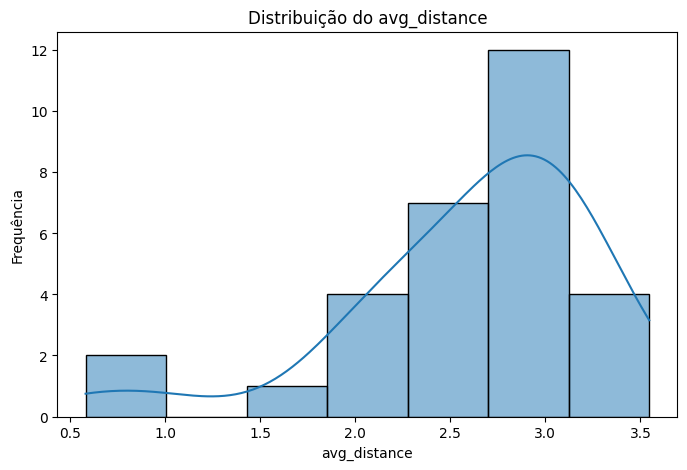

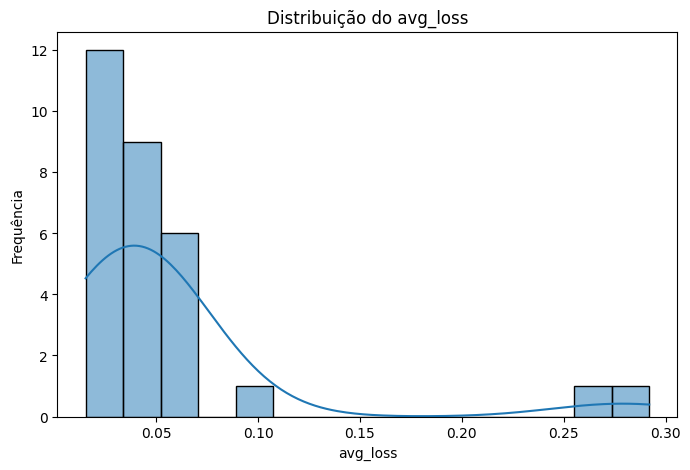

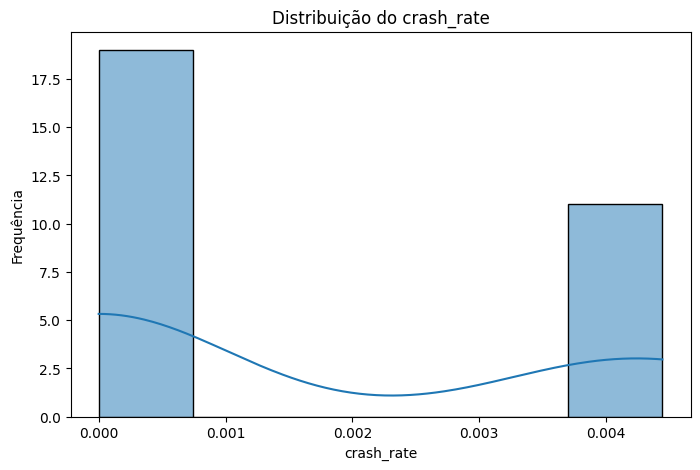

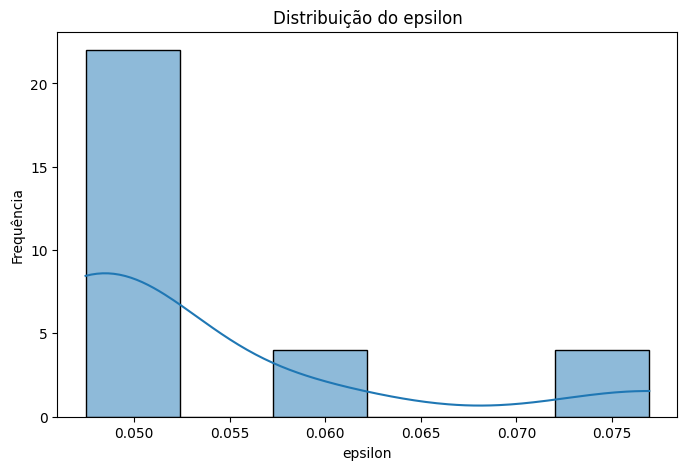

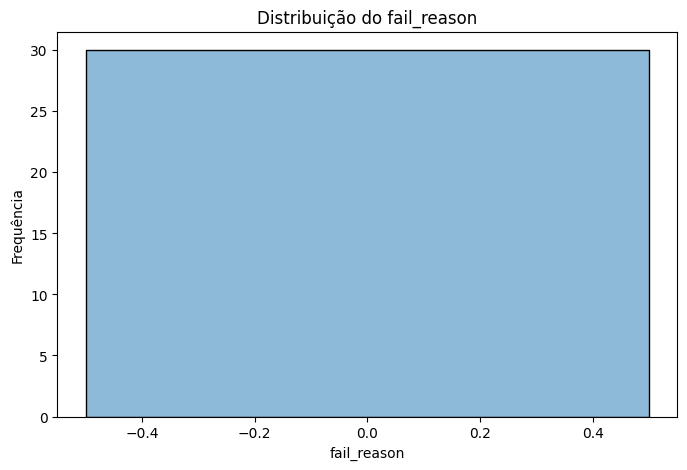

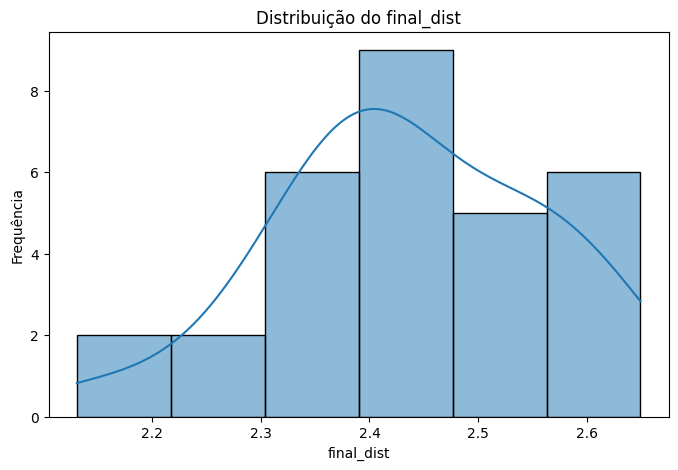

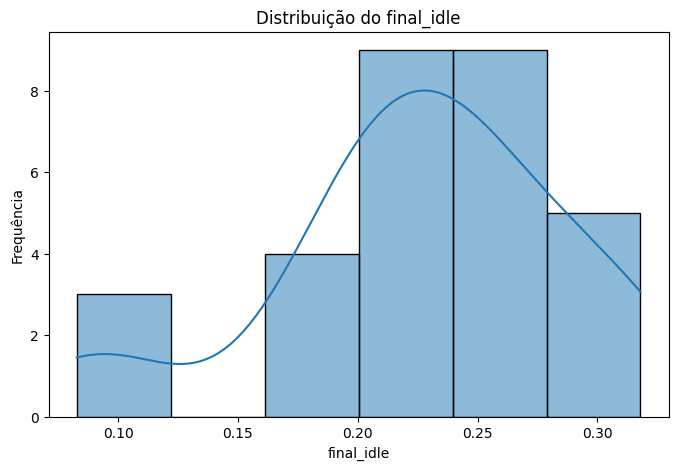

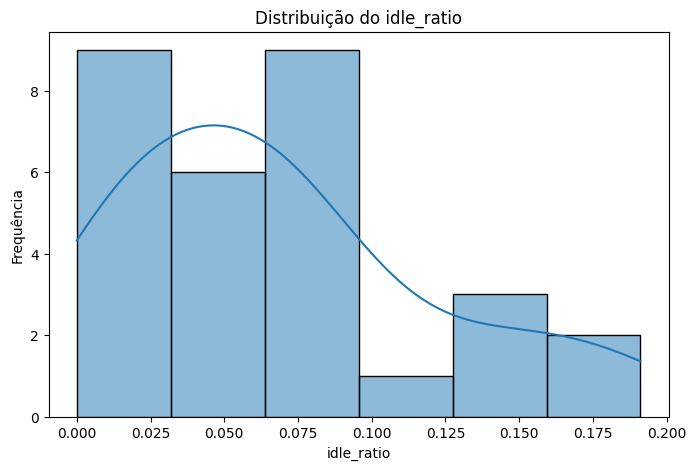

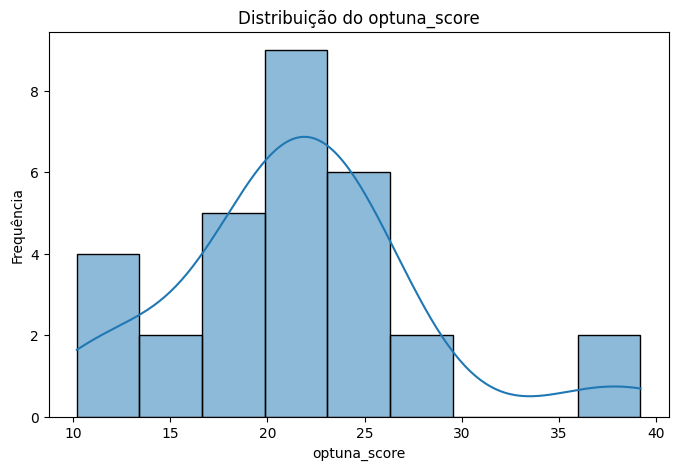

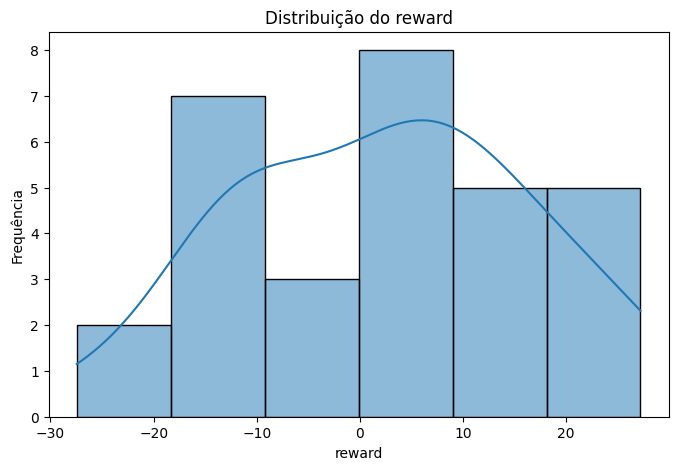

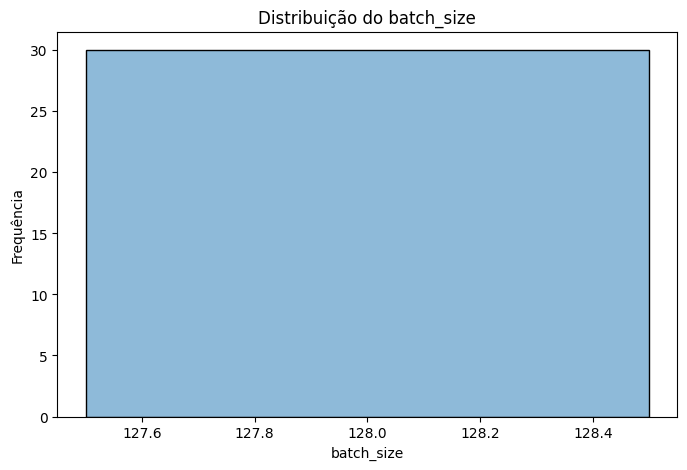

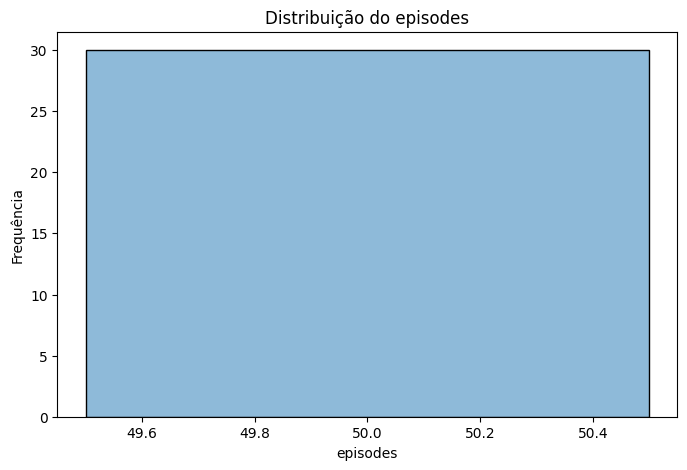

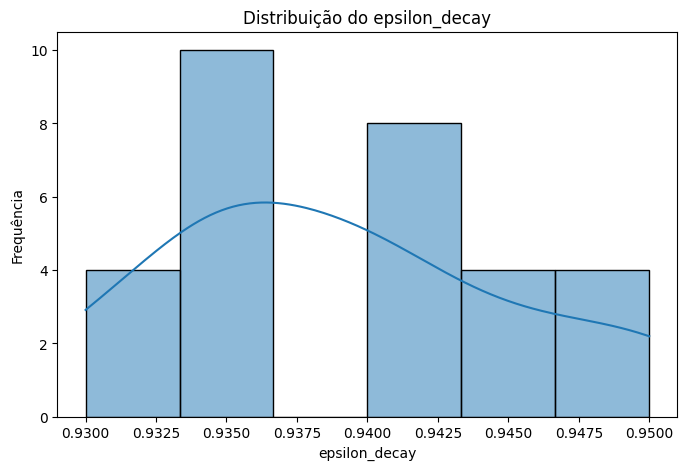

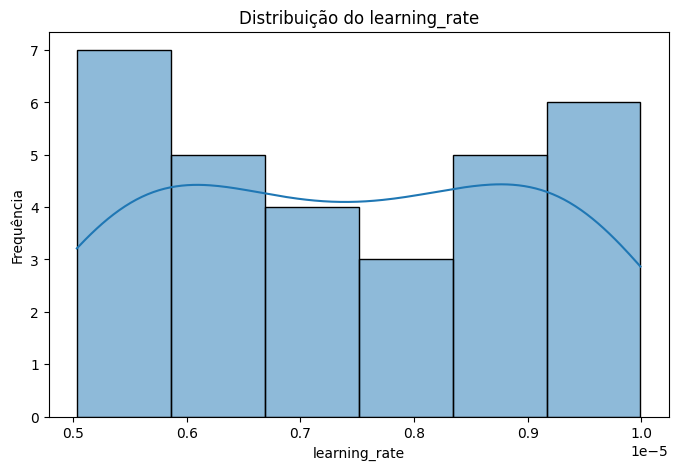

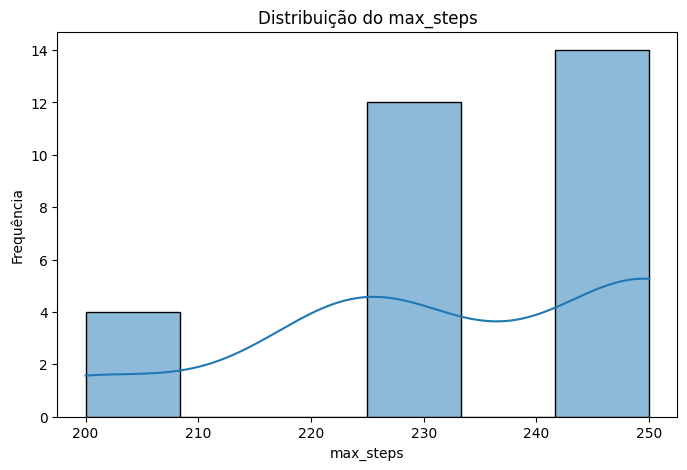

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt


def show_histogram(column_name):
    plt.figure(figsize=(8, 5))
    sns.histplot(df[column_name], kde=True) # kde=True adiciona uma linha de densidade
    plt.title(f'Distribuição do {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequência')

for column in df.select_dtypes(include=['float64', 'int64']).columns:
    show_histogram(column)

plt.show()


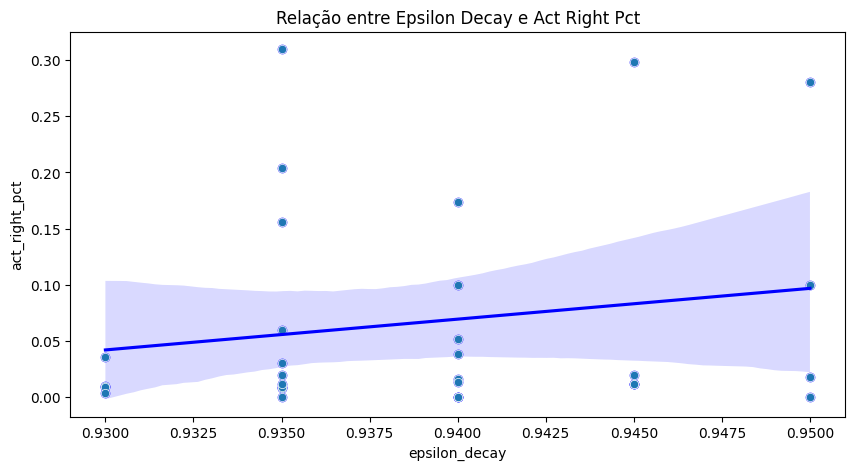

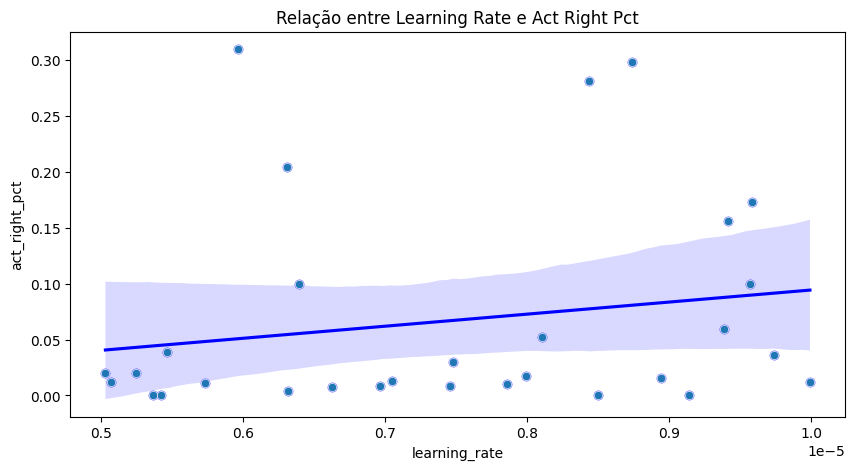

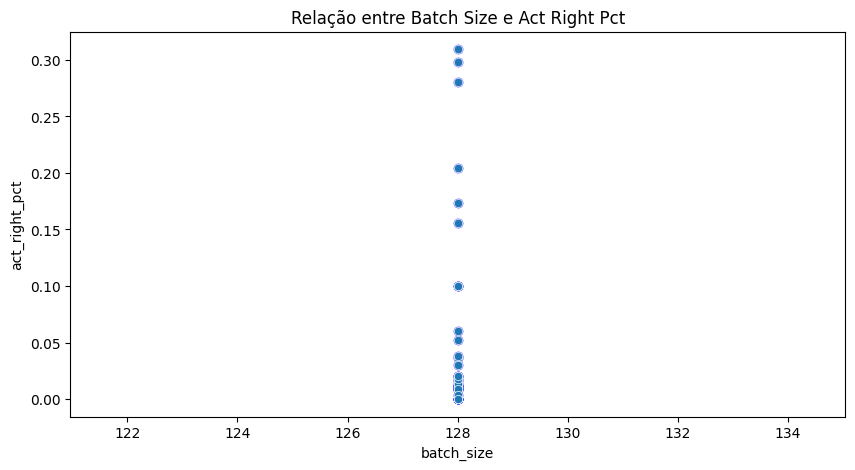

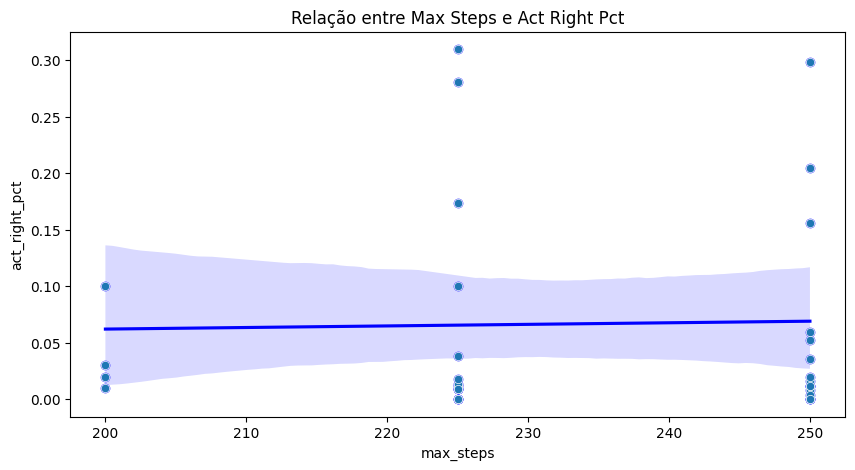

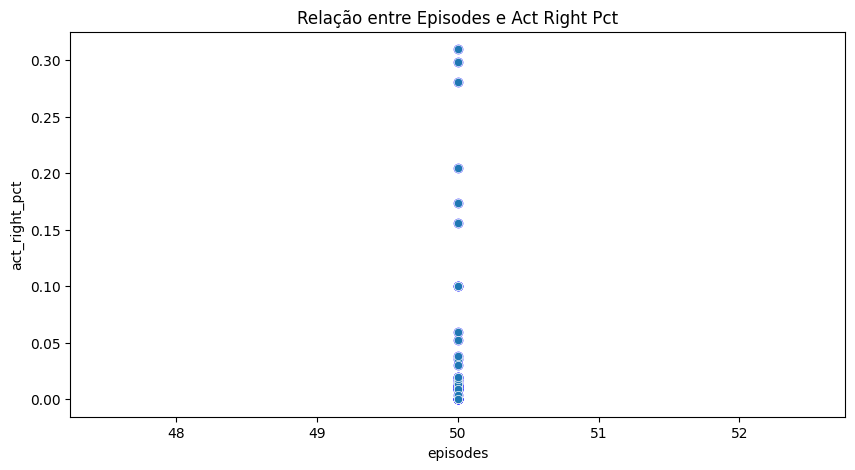

In [8]:
# Exemplo: Existe relação entre o parâmetro epsilon e o resultado final (optuna_score)?
metrics = ['optuna_score', 'avg_distance', 'avg_loss', 'crash_rate', 'epsilon', 
           'fail_reason', 'reward', 'act_back_pct', 'act_fwd_pct', 'act_left_pct', 'act_right_pct',
           'act_stop_pct','final_dist', 'final_idle', 'idle_ratio',]
params = ['epsilon_decay', 'learning_rate', 'batch_size', 'max_steps', 'episodes']

def _to_pascal_case(snake_str):
    components = snake_str.split('_')
    return ' '.join(x.title() for x in components)

def show_correlation(x, y):
    plt.figure(figsize=(10, 5))
    sns.scatterplot(x=x, y=y, data=df, zorder=2)
    sns.regplot(x=x, y=y, data=df, color='blue')
    plt.title(f'Relação entre {_to_pascal_case(x)} e {_to_pascal_case(y)}')
    plt.xlabel(x)
    plt.ylabel(y)

for param in params:
    show_correlation(param, 'act_right_pct')
plt.show()



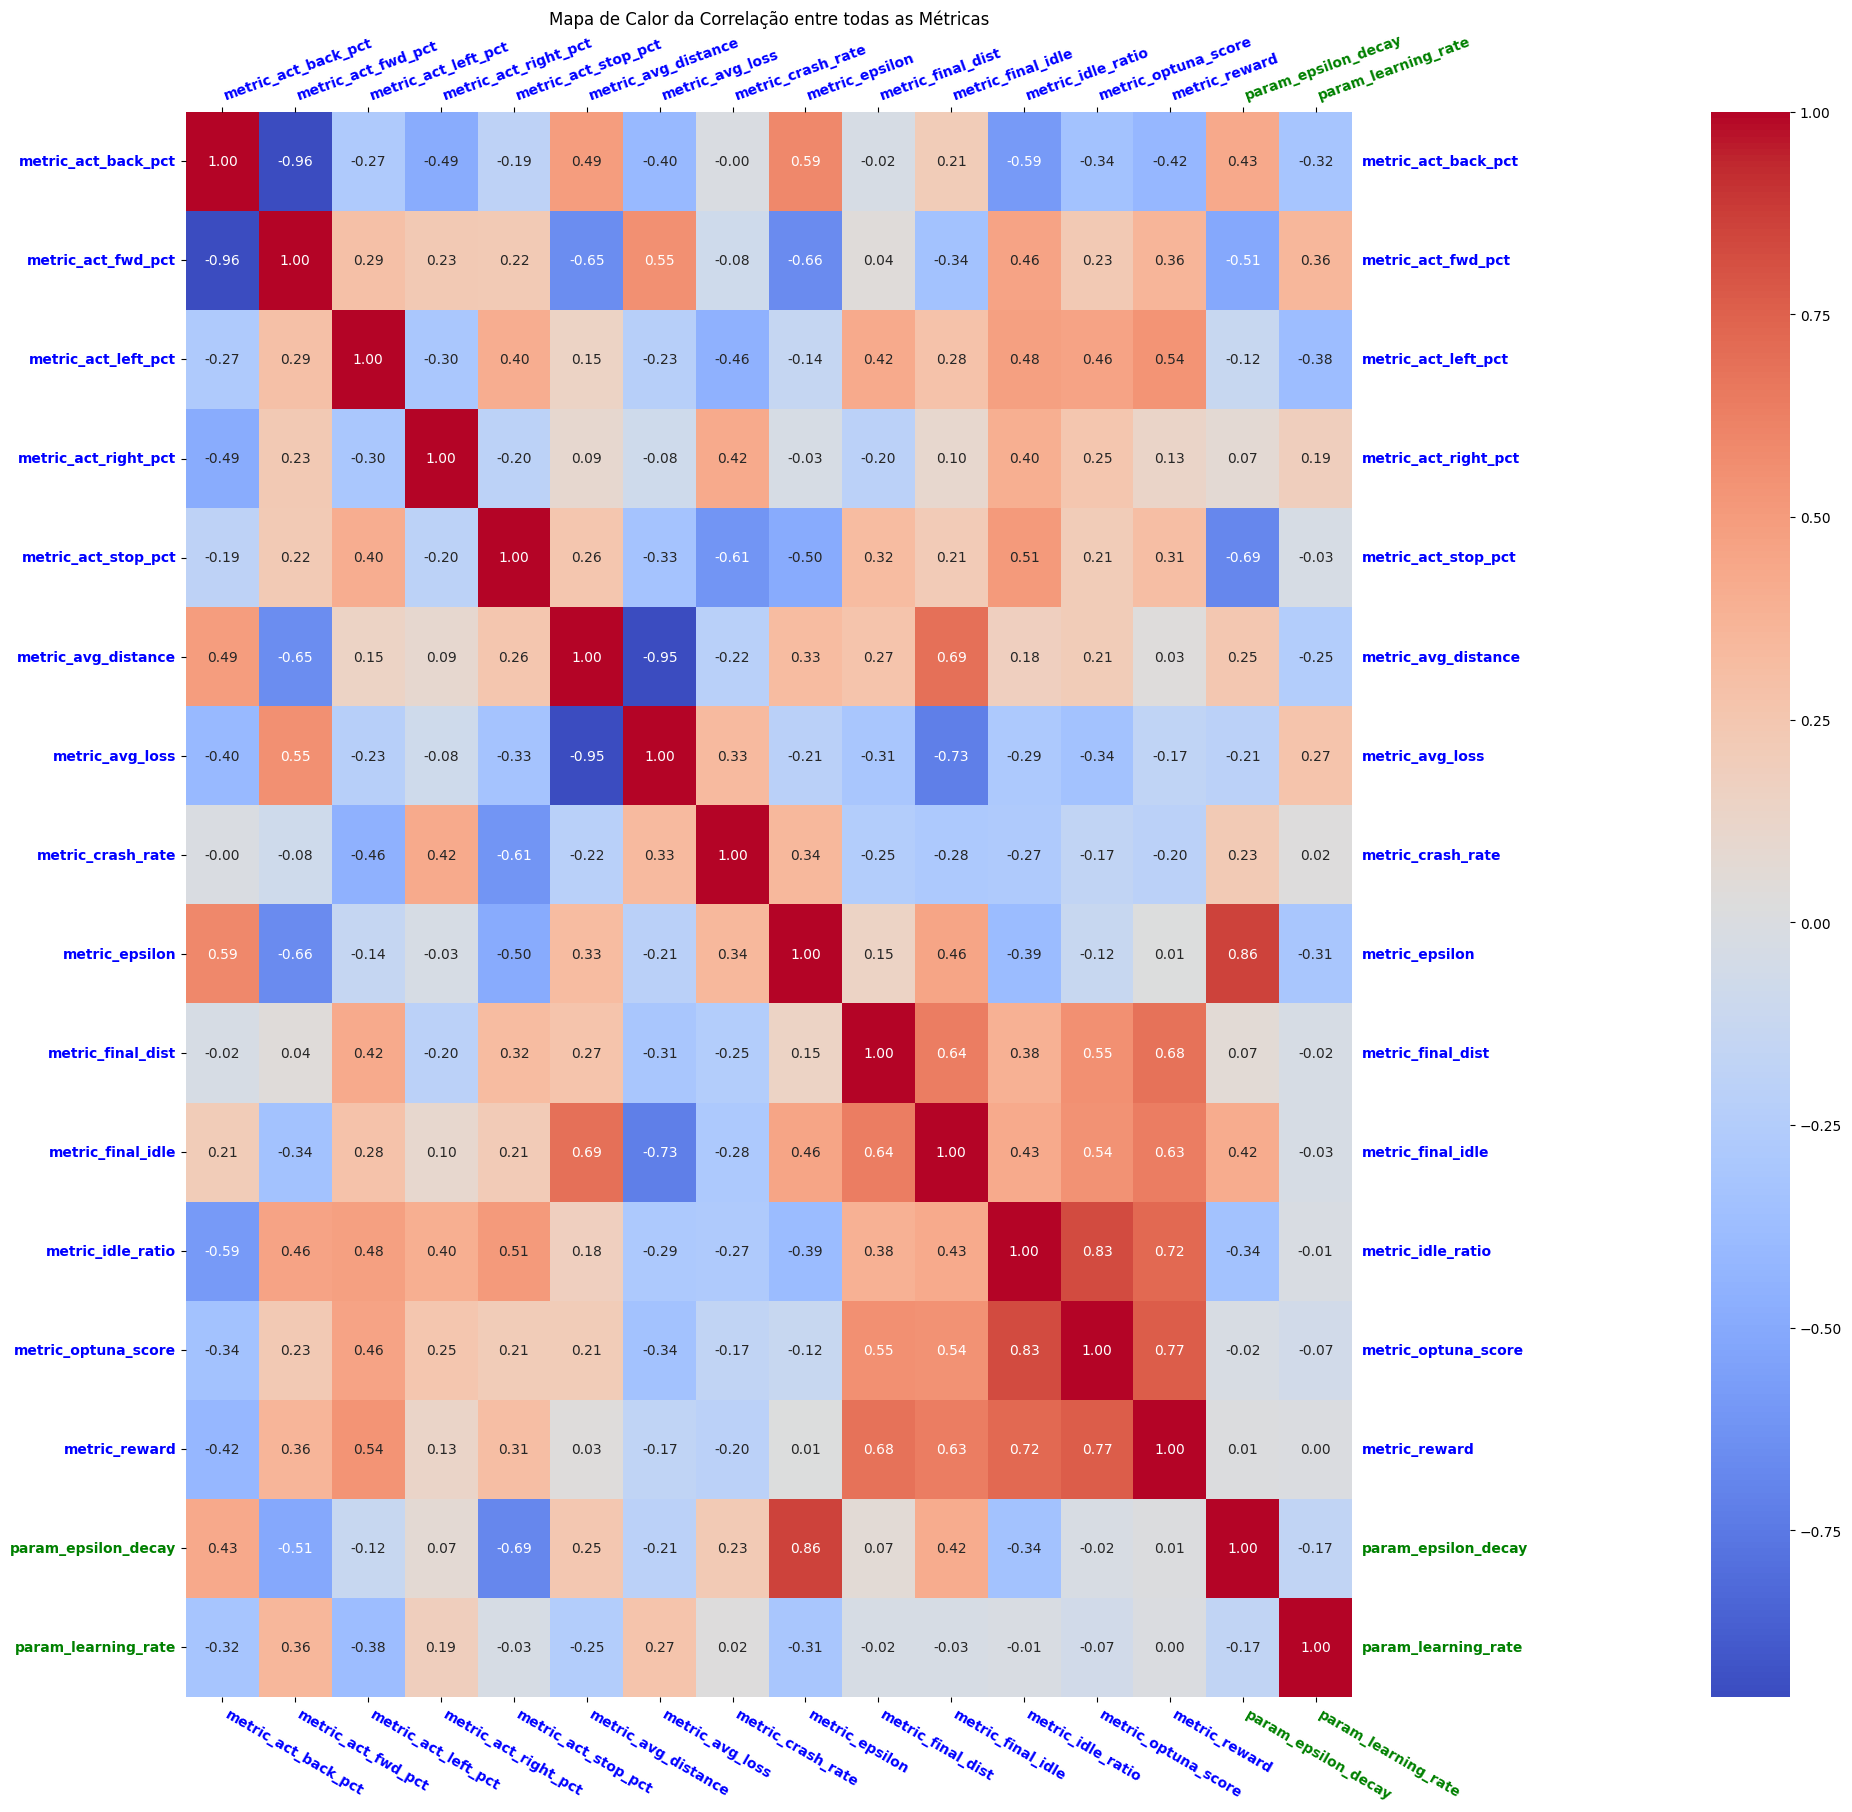

In [14]:
temp = df.loc[df['max_steps'] == 250]\
        .drop(columns=['run_id', 'max_steps','parent_run_id', 'run_name', 'architecture', 'fail_reason', 'episodes', 'batch_size'])
        
        

#rename colummns, add param and metric prefixes
temp = temp.rename(columns={col: f"param_{col}" if col in params 
                            else f"metric_{col}" for col in temp.columns})
correlation_matrix = temp.corr()
plt.figure(figsize=(20, 18))

# Usamos annot=True para mostrar o valor da correlação dentro do quadrado
ax = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar_kws={"pad": 0.20})

ax.tick_params(
    top=True, 
    labeltop=True, 
    bottom=True, 
    labelbottom=True,
    labelright=True,
)

# 1. Create a figure and axes for the main plot

xticklabels = ax.get_xticklabels()
for tick in xticklabels:
    text = tick.get_text()
    _, y = tick.get_position()
    tick.set_color('blue' if 'metric_' in text else 'green')
    if y > 0:
        tick.set_fontweight('bold')
        tick.set_rotation(20)
        tick.set_horizontalalignment('left')
    else:
        tick.set_fontweight('bold')
        tick.set_rotation(-30)
        tick.set_horizontalalignment('left')
        
        
yticklabels = ax.get_yticklabels()
for tick in yticklabels:
    text = tick.get_text()
    x, _ = tick.get_position()
    tick.set_color('blue' if 'metric_' in text else 'green')
    if x > 0:
        tick.set_fontweight('bold')
        tick.set_rotation(0)
        tick.set_verticalalignment('center')
    else:
        tick.set_fontweight('bold')
        # tick.set_rotation(-30)
        # tick.set_horizontalalignment('left')

plt.tight_layout()
plt.title('Mapa de Calor da Correlação entre todas as Métricas')
plt.show()

In [1]:
import numpy as np
valores = [0.1,0.2,0.4,0.3,0.1]
valores_crus = [*'0'*int(valores[0]*123456), *'1'*int(valores[1]*123456), 
                *'2'*int(valores[2]*123456), 
                *'3'*int(valores[3]*123456), 
                *'4'*int(valores[4]*123456)]


valores_crus = list(map(int, valores_crus))
total = len(valores_crus)
# f'std: {np.std(valores)}, mean: {np.mean(valores)}, max: {np.max(valores)}, min: {np.min(valores)}, median: {np.median(valores)}'
print(f'std: {np.std(valores_crus)}, mean: {np.mean(valores_crus)}, median: {np.median(valores_crus)}, cov: {np.std(valores_crus)/np.mean(valores_crus)}')
actions = ['stop', 'fwd', 'back', 'left', 'right']
dict_actions = {i:len([v for v in valores_crus if v == i]) for i in range(len(actions))}
actions_counts = list(dict_actions.values())
for i, count in enumerate(np.bincount(valores_crus)):
    print(f'Action {actions[i]}: Count: {count}, Percentage: {count/total:.2%}')

print(np.std(actions_counts)/sum(actions_counts))

std: 1.0832977996413824, mean: 2.090906413154736, median: 2.0, cov: 0.5180996111666781
Action stop: Count: 12345, Percentage: 9.09%
Action fwd: Count: 24691, Percentage: 18.18%
Action back: Count: 49382, Percentage: 36.36%
Action left: Count: 37036, Percentage: 27.27%
Action right: Count: 12345, Percentage: 9.09%
0.10601948853718104
